## 1 Packages

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
np.random.seed(42)
tf.random.set_seed(42)

## 2 Loading and data visualization

In [29]:
# Load the dataset
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

# Separate features and target (using all data)
X_full = df.drop(columns=['Class']).values # Use all 16 features
y_full = df['Class'].values # Use all 7 classes

# Encode the 7 class labels to integers (0 to 6)
label_encoder_full = LabelEncoder()
y_encoded_full = label_encoder_full.fit_transform(y_full)
num_classes = len(label_encoder_full.classes_)
target_names = label_encoder_full.classes_
input_shape = X_full.shape[1] # 16 features

print(f"Full dataset shape: {X_full.shape}")
print(f"Number of classes: {num_classes}")

# Split the full dataset (67% train, 16.5% CV, 16.5% test)
# This uses the same split ratios as the Logistic Regression notebooks
X_train_full, X_, y_train_full, y_ = train_test_split(
    X_full, y_encoded_full, test_size=0.33, random_state=42, stratify=y_encoded_full
)

X_cv_full, X_test_full, y_cv_full, y_test_full = train_test_split(
    X_, y_, test_size=0.5, random_state=42, stratify=y_
)

# Scale all 16 features
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_full)
X_cv_scaled = scaler_full.transform(X_cv_full)
X_test_scaled = scaler_full.transform(X_test_full)

# desired order
labels_desired_order = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

print(f"Train shapes: X={X_train_scaled.shape}, y={y_train_full.shape}")
print(f"CV shapes: X={X_cv_scaled.shape}, y={y_cv_full.shape}")
print(f"Test shapes: X={X_test_scaled.shape}, y={y_test_full.shape}")

# Convert y to one-hot for TensorFlow (categorical crossentropy)
y_train_onehot = tf.keras.utils.to_categorical(y_train_full, num_classes)
y_cv_onehot = tf.keras.utils.to_categorical(y_cv_full, num_classes)
y_test_onehot = tf.keras.utils.to_categorical(y_test_full, num_classes)

Full dataset shape: (13611, 16)
Number of classes: 7
Train shapes: X=(9119, 16), y=(9119,)
CV shapes: X=(2246, 16), y=(2246,)
Test shapes: X=(2246, 16), y=(2246,)


## 3 Model Definition (3 Layers with L2 Regularization)

In [30]:
# Define 3-layer neural network model
def create_model(input_size, hidden_size1, hidden_size2, num_classes, reg=0.0):
    model = Sequential([
        Dense(hidden_size1, activation='relu', input_shape=(input_size,), kernel_regularizer=l2(reg)),  # Layer 1
        Dense(hidden_size2, activation='relu', kernel_regularizer=l2(reg)),  # Layer 2
        Dense(num_classes, activation='softmax', kernel_regularizer=l2(reg))  # Layer 3 (output)
    ])
    return model

# Hyperparameters
input_size = X_full.shape[1]  # 16 features
hidden_size1 = 128
hidden_size2 = 64
learning_rate = 0.001
num_epochs = 100
batch_size = 64

## 4 Training

In [31]:
# Train the model, calculate cost, and plot it
model = create_model(input_size, hidden_size1, hidden_size2, num_classes)
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_scaled, y_train_onehot,
    validation_data=(X_cv_scaled, y_cv_onehot),
    epochs=num_epochs,
    batch_size=batch_size,
    verbose=1
)

print("\nModel Summary:")
model.summary()

Epoch 1/100


/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8301 - loss: 0.5719 - val_accuracy: 0.9190 - val_loss: 0.2421
Epoch 2/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9192 - loss: 0.2304 - val_accuracy: 0.9252 - val_loss: 0.2069
Epoch 3/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9246 - loss: 0.2087 - val_accuracy: 0.9252 - val_loss: 0.1995
Epoch 4/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9263 - loss: 0.2004 - val_accuracy: 0.9248 - val_loss: 0.1961
Epoch 5/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9271 - loss: 0.1957 - val_accuracy: 0.9265 - val_loss: 0.1943
Epoch 6/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9288 - loss: 0.1922 - val_accuracy: 0.9265 - val_loss: 0.1930
Epoch 7/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9295 - loss: 0.1894 - val_accuracy: 0.9261 - val_loss: 0.1920
Epoch 8/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9301 - loss: 0.1872 - val_accuracy: 0.9265

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,663 (127.59 KB)

 Trainable params: 10,887 (42.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,776 (85.07 KB)

## 5 Evaluation and plotting

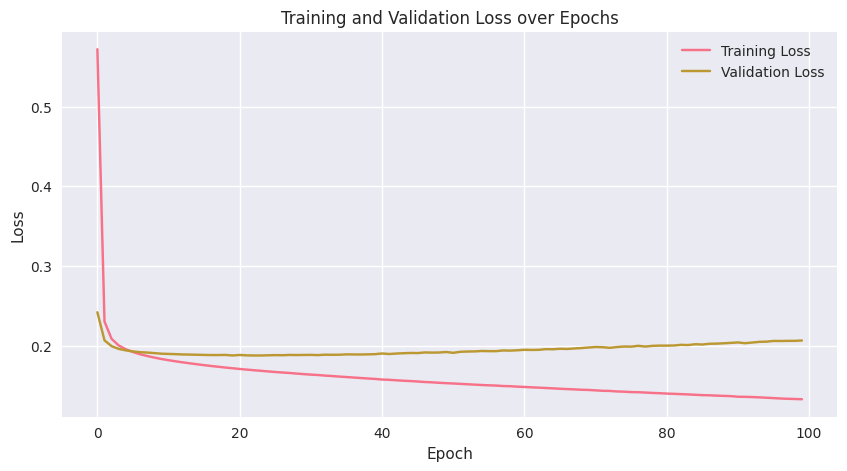

In [32]:
# Plot training cost (loss)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

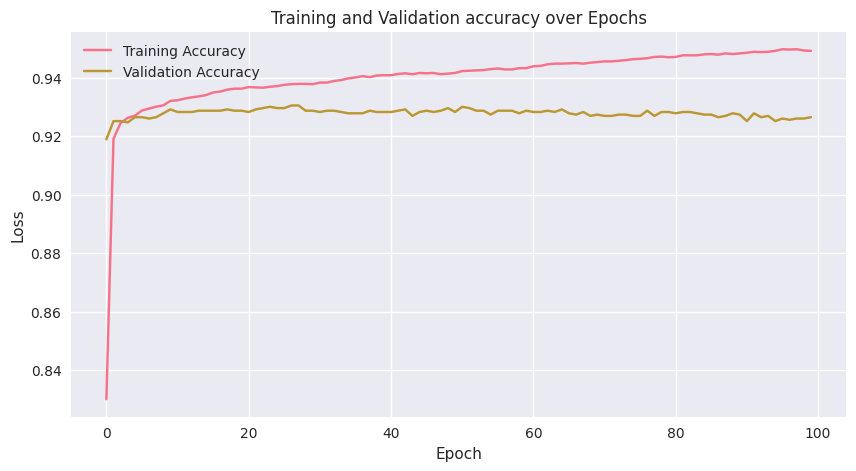

In [33]:
# Plot training cost (loss)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6 Hyperparameter Regularization

In [34]:
# Hyperparameter regularization (tune L2 regularization)
print('\nHyperparameter Tuning for Regularization (L2):')
reg_values = [0.0, 0.0001, 0.001, 0.01]
reg_results = {}

for reg in reg_values:
    print(f'Training with L2 regularization={reg}')
    model = create_model(input_size, hidden_size1, hidden_size2, num_classes, reg=reg)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(
        X_train_scaled, y_train_onehot,
        epochs=num_epochs,
        batch_size=batch_size,
        verbose=0
    )
    
    # Evaluate on validation set
    val_loss, val_acc = model.evaluate(X_cv_scaled, y_cv_onehot, verbose=0)
    reg_results[reg] = val_acc
    print(f'L2 {reg}: Validation Accuracy {val_acc:.4f}')

# Select best regularization
best_reg = max(reg_results, key=reg_results.get)
print(f'Best L2: {best_reg} with Val Acc: {reg_results[best_reg]:.4f}')

# Retrain with best reg for final evaluation
model = create_model(input_size, hidden_size1, hidden_size2, num_classes, reg=best_reg)
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(
    X_train_scaled, y_train_onehot,
    epochs=num_epochs,
    batch_size=batch_size,
    verbose=0
)


Hyperparameter Tuning for Regularization (L2):
Training with L2 regularization=0.0
L2 0.0: Validation Accuracy 0.9243
Training with L2 regularization=0.0001
L2 0.0001: Validation Accuracy 0.9292
Training with L2 regularization=0.001
L2 0.001: Validation Accuracy 0.9265
Training with L2 regularization=0.01
L2 0.01: Validation Accuracy 0.9239
Best L2: 0.0001 with Val Acc: 0.9292



Validation Accuracy at Different Epochs:
At epoch 10: 0.9292
At epoch 20: 0.9288
At epoch 50: 0.9283
At epoch 100: 0.9265

Final Test Accuracy: 0.9270
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


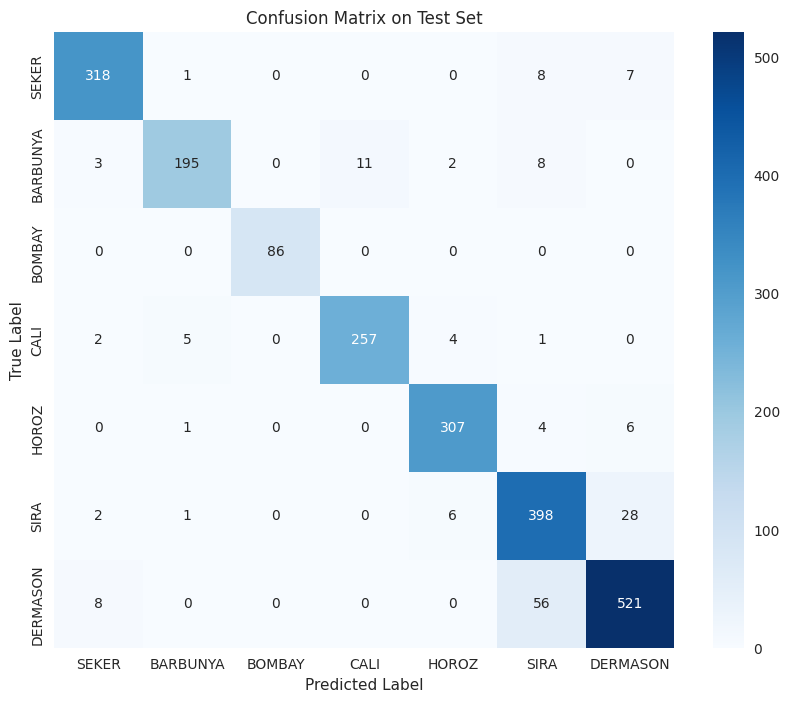

In [35]:
# Evaluate accuracy for different number of iterations (epochs)
# (We can access from history, but since we retrained, simulate by training incrementally)
print('\nValidation Accuracy at Different Epochs:')
val_accuracies = history.history['val_accuracy']  # From initial training for illustration
for epoch_check in [10, 20, 50, 100]:
    print(f'At epoch {epoch_check}: {val_accuracies[epoch_check - 1]:.4f}')

# Final test accuracy
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

# 6. Plot confusion matrix
y_test_pred = np.argmax(model.predict(X_test_scaled), axis=1)
cm = confusion_matrix(y_test_full, y_test_pred, labels=label_encoder_full.transform(labels_desired_order))
conf_df = pd.DataFrame(
    cm,
    index=labels_desired_order, 
    columns=labels_desired_order
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_desired_order,
            yticklabels=labels_desired_order,)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [36]:
# Classification Report
print("\nClassification Report (Test Data):")
print(classification_report(y_test_full, y_test_pred, target_names=target_names))


Classification Report (Test Data):
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.89      0.92       219
      BOMBAY       1.00      1.00      1.00        86
        CALI       0.96      0.96      0.96       269
    DERMASON       0.93      0.89      0.91       585
       HOROZ       0.96      0.97      0.96       318
       SEKER       0.95      0.95      0.95       334
        SIRA       0.84      0.91      0.87       435

    accuracy                           0.93      2246
   macro avg       0.94      0.94      0.94      2246
weighted avg       0.93      0.93      0.93      2246

